# Dashboard Visualisasi — Rasio Dosen:Mahasiswa Universitas Siliwangi
**Sumber Data:** `master_looker_unsil.csv` dari Google Drive (`My Drive/College/Processed/`)  
**Periode:** Ganjil 2023 — Ganjil 2025  
**Output Grafik:** Google Drive (`My Drive/College/Visualizations/`)

---
## 0. Mount Google Drive

Jalankan cell ini terlebih dahulu untuk mengakses data dari Google Drive.

In [1]:
# [LOCAL MODE] - Google Drive tidak diperlukan
print('Mode: Lokal OK')


Mode: Lokal OK


---
## 1. Import Library & Load Data

In [2]:
import seaborn as sns
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Load data dari path lokal
master_path = 'd:/Code/Tugas Akhir/Data/Processed/master_looker_unsil.csv'
VIZ_OUT = 'd:/Code/Tugas Akhir/Outputs/Visualizations'

df = pd.read_csv(master_path)

# Pastikan kolom numerik
df['nilai_rasio'] = pd.to_numeric(df['nilai_rasio'], errors='coerce')

PERIOD_ORDER = ['Ganjil 2023', 'Genap 2023', 'Ganjil 2024', 'Genap 2024', 'Ganjil 2025']
df['tahun_pelaporan'] = pd.Categorical(df['tahun_pelaporan'], categories=PERIOD_ORDER, ordered=True)

print(f'Data loaded: {len(df)} baris, {df["nama_program_studi"].nunique()} prodi, {df["tahun_pelaporan"].nunique()} periode')
print('Kolom tersedia:', df.columns.tolist())

# Definisikan warna
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
PATH_VIZ = VIZ_OUT


Data loaded: 200 baris, 34 prodi, 5 periode
Kolom tersedia: ['tahun_pelaporan', 'semester', 'tahun', 'nama_program_studi', 'jenjang', 'status_prodi', 'akreditasi_prodi', 'nama_universitas', 'jumlah_mahasiswa', 'jumlah_dosen_penghitung_rasio', 'dosen_tetap', 'dosen_tidak_tetap', 'total_dosen', 'rasio_dosen_mahasiswa', 'nilai_rasio', 'kota', 'provinsi', 'kode_pt']


---
## 2. Visualisasi Tingkat Institusi

Tiga panel: tren rata-rata rasio, total mahasiswa, total dosen per semester.

[TABEL] Ringkasan Tingkat Institusi:
  tahun_pelaporan  total_mahasiswa  total_dosen  rata_rasio
0     Ganjil 2023            18702          431   24.905625
1      Genap 2023            17141          431   24.776250
2     Ganjil 2024            23357          526   24.578108
3      Genap 2024            18232          524   22.842703
4     Ganjil 2025            22789          549   22.621622


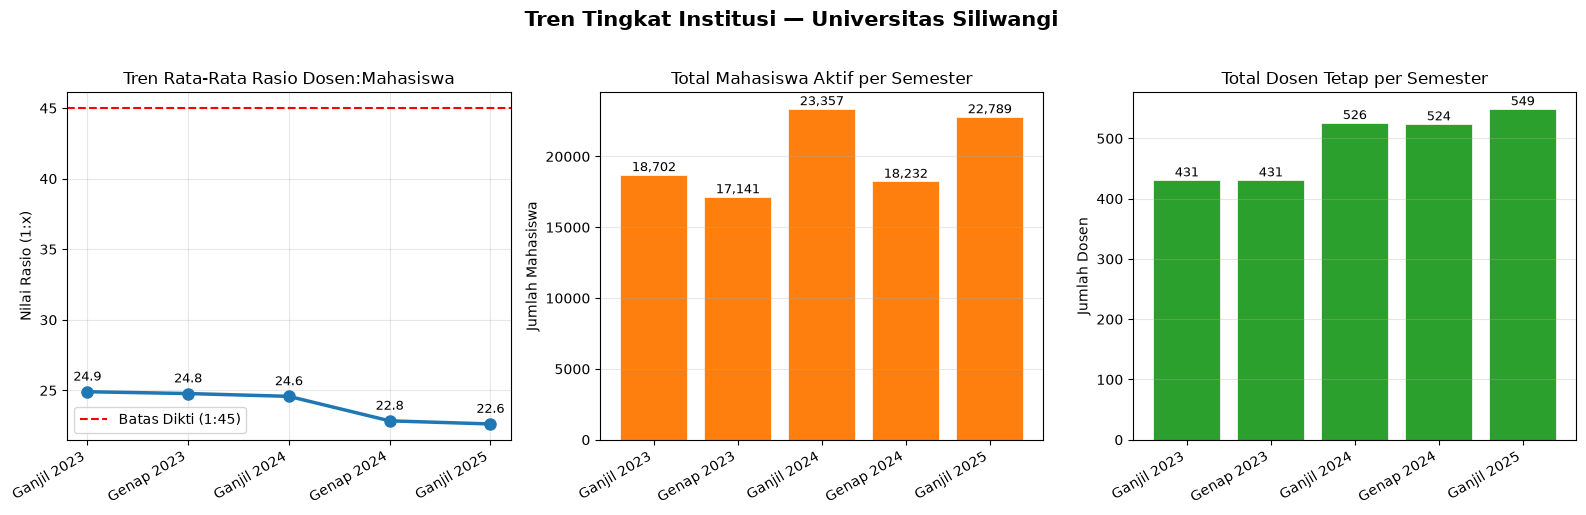

✅ Grafik disimpan ke Google Drive: d:/Code/Tugas Akhir/Outputs/Visualizations\viz_institusi.png


In [3]:
# Agregasi institusi per periode
# Catatan: mean() secara default skipna=True → baris NaN dikecualikan (konsisten dengan Looker Studio)
inst = df.groupby('tahun_pelaporan', observed=True).agg(
    total_mahasiswa=('jumlah_mahasiswa','sum'),
    total_dosen=('total_dosen','sum'),
    rata_rasio=('nilai_rasio','mean')
).reset_index()

print('[TABEL] Ringkasan Tingkat Institusi:')
print(inst)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Tren Tingkat Institusi — Universitas Siliwangi', fontsize=15, fontweight='bold', y=1.02)

# Panel kiri: Line chart tren rasio
ax = axes[0]
ax.plot(inst['tahun_pelaporan'], inst['rata_rasio'], marker='o', color=COLORS[0], linewidth=2.5, markersize=8)
ax.axhline(y=45, color='red', linestyle='--', linewidth=1.5, label='Batas Dikti (1:45)')
ax.set_title('Tren Rata-Rata Rasio Dosen:Mahasiswa')
ax.set_ylabel('Nilai Rasio (1:x)')
ax.set_xticklabels(inst['tahun_pelaporan'], rotation=30, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)
for i, (x, y) in enumerate(zip(range(len(inst)), inst['rata_rasio'])):
    ax.annotate(f'{y:.1f}', (i, y), textcoords='offset points', xytext=(0,8), ha='center', fontsize=9)

# Panel tengah: Bar chart total mahasiswa
ax = axes[1]
bars = ax.bar(inst['tahun_pelaporan'], inst['total_mahasiswa'], color=COLORS[1], edgecolor='white', linewidth=0.5)
ax.set_title('Total Mahasiswa Aktif per Semester')
ax.set_ylabel('Jumlah Mahasiswa')
ax.set_xticklabels(inst['tahun_pelaporan'], rotation=30, ha='right')
ax.grid(True, axis='y', alpha=0.3)
for bar, v in zip(bars, inst['total_mahasiswa']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50, f'{int(v):,}', ha='center', va='bottom', fontsize=9)

# Panel kanan: Bar chart total dosen
ax = axes[2]
bars = ax.bar(inst['tahun_pelaporan'], inst['total_dosen'], color=COLORS[2], edgecolor='white', linewidth=0.5)
ax.set_title('Total Dosen Tetap per Semester')
ax.set_ylabel('Jumlah Dosen')
ax.set_xticklabels(inst['tahun_pelaporan'], rotation=30, ha='right')
ax.grid(True, axis='y', alpha=0.3)
for bar, v in zip(bars, inst['total_dosen']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{int(v):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PATH_VIZ, 'viz_institusi.png'), bbox_inches='tight', dpi=150)
plt.show()
print('✅ Grafik disimpan ke Google Drive:', os.path.join(PATH_VIZ, 'viz_institusi.png'))

---
## 3. Visualisasi Tingkat Program Studi

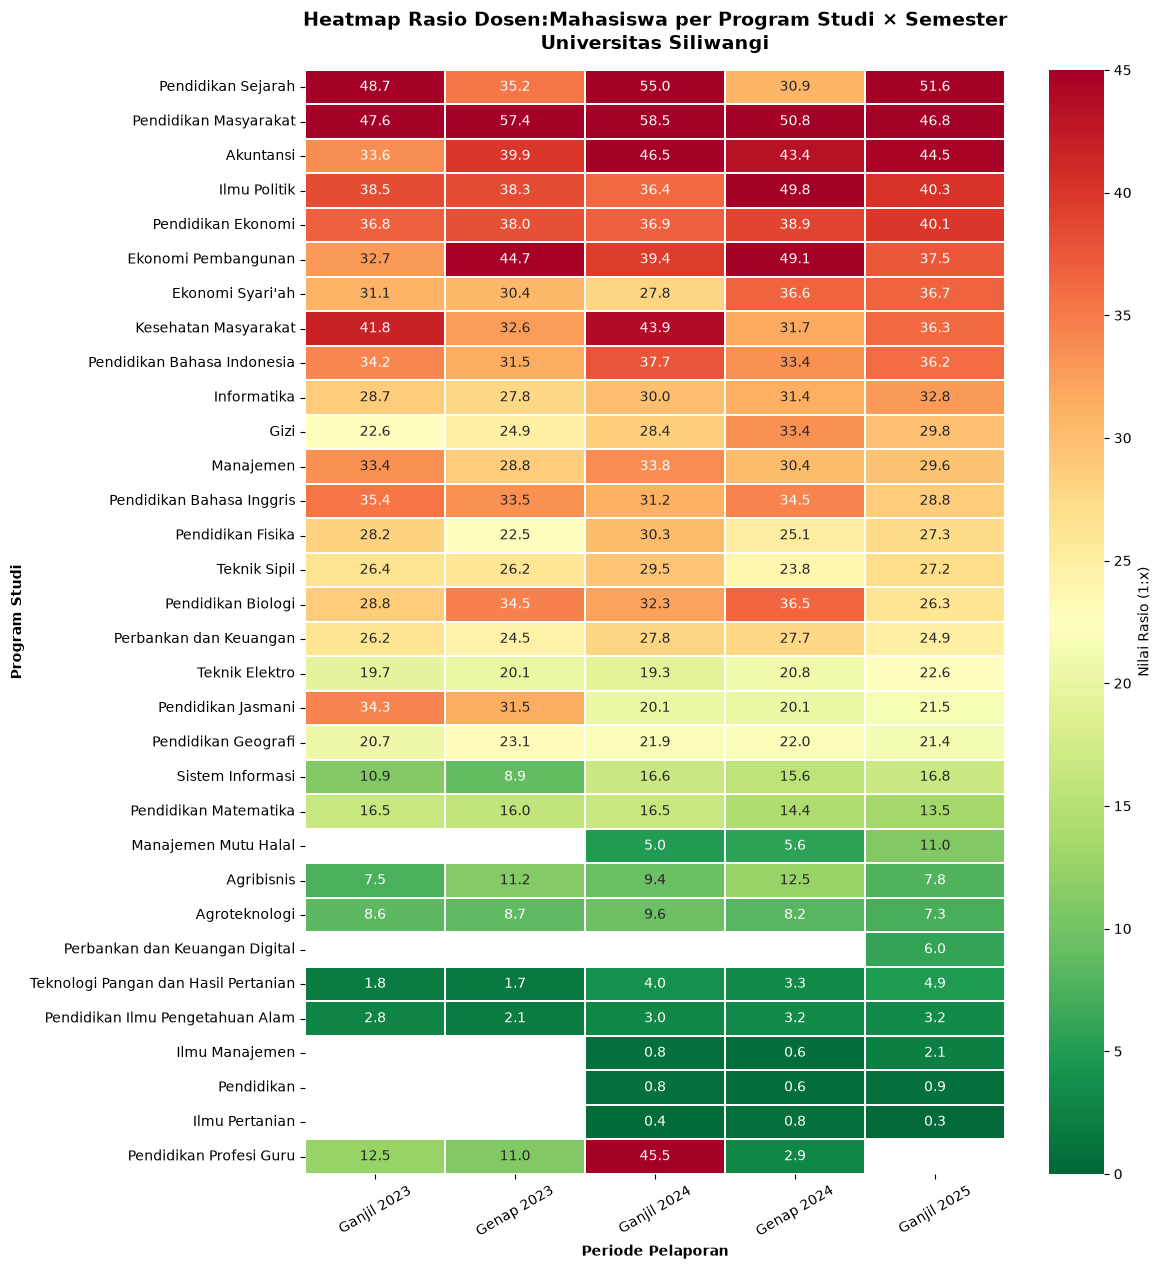

✅ Grafik disimpan ke Google Drive: d:/Code/Tugas Akhir/Outputs/Visualizations\heatmap_prodi_semester.png


In [4]:
# Heatmap rasio per prodi × per semester
# Sel kosong (blank) pada heatmap = nilai NaN = prodi dengan 0 mahasiswa di periode tersebut
pivot = df.pivot_table(index='nama_program_studi', columns='tahun_pelaporan',
                       values='nilai_rasio', aggfunc='mean', observed=True)
pivot = pivot.reindex(columns=PERIOD_ORDER)
pivot = pivot.sort_values(PERIOD_ORDER[-1], ascending=False)

fig, ax = plt.subplots(figsize=(12, max(8, len(pivot)*0.4)))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', linewidths=0.3,
            cbar_kws={'label':'Nilai Rasio (1:x)'}, ax=ax,
            vmin=0, vmax=45)
ax.set_title('Heatmap Rasio Dosen:Mahasiswa per Program Studi × Semester\nUniversitas Siliwangi',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Periode Pelaporan', fontweight='bold')
ax.set_ylabel('Program Studi', fontweight='bold')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(PATH_VIZ, 'heatmap_prodi_semester.png'), bbox_inches='tight', dpi=150)
plt.show()
print('✅ Grafik disimpan ke Google Drive:', os.path.join(PATH_VIZ, 'heatmap_prodi_semester.png'))

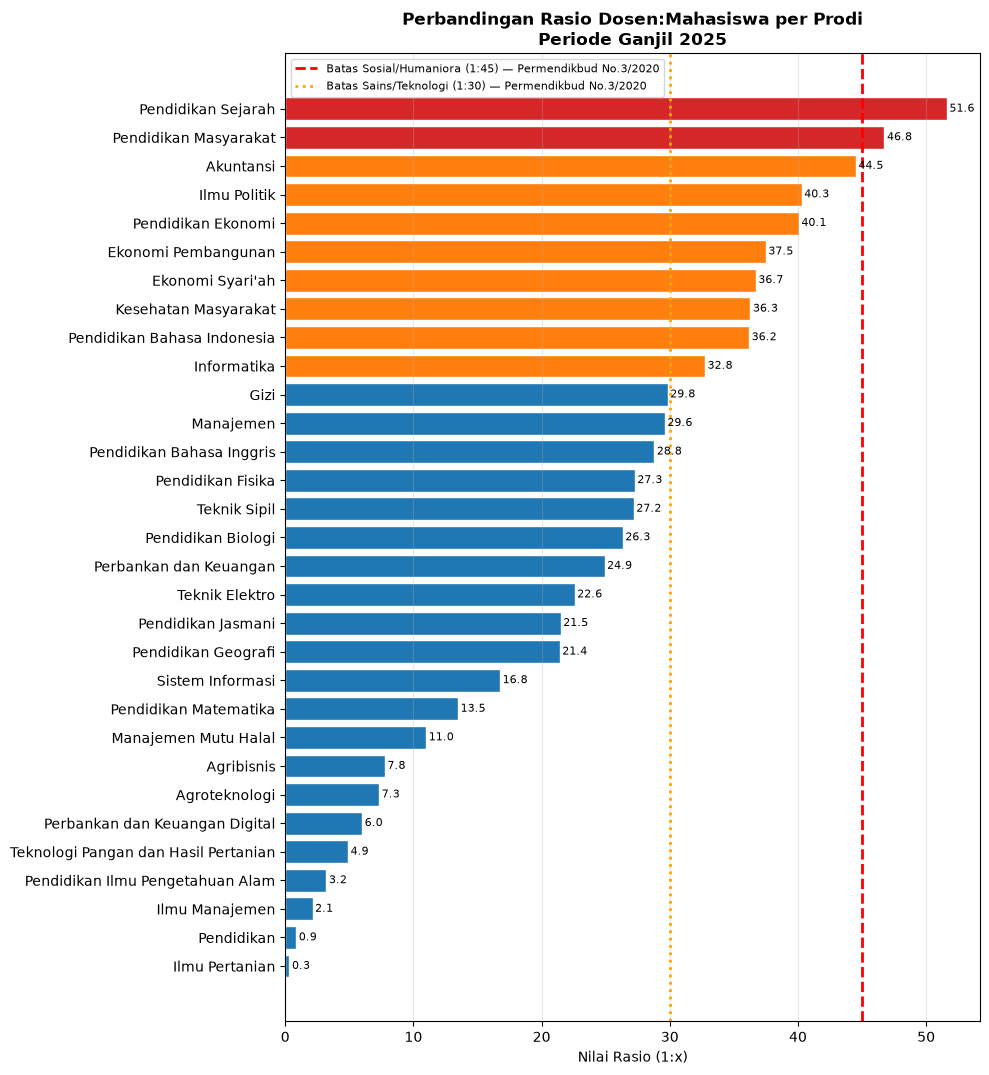

✅ Grafik disimpan ke Google Drive: d:/Code/Tugas Akhir/Outputs/Visualizations\bar_rasio_prodi_terbaru.png


In [5]:
# Bar chart perbandingan rasio antar prodi - periode terbaru (Ganjil 2025)
# Prodi dengan nilai NaN tidak ditampilkan (otomatis dikecualikan oleh matplotlib)
latest = PERIOD_ORDER[-1]
df_latest = df[df['tahun_pelaporan']==latest].copy()
df_latest = df_latest.groupby('nama_program_studi', observed=True)['nilai_rasio'].mean().reset_index()
df_latest = df_latest.dropna(subset=['nilai_rasio'])  # Eksklusi prodi dengan nilai NaN
df_latest = df_latest.sort_values('nilai_rasio', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(8, len(df_latest)*0.35)))
# 3-tier warna: >45 (Merah), >30 (Oranye), <30 (Biru)
colors = ['#d62728' if v > 45 else '#ff7f0e' if v > 30 else '#1f77b4' for v in df_latest['nilai_rasio']]
bars = ax.barh(df_latest['nama_program_studi'], df_latest['nilai_rasio'], color=colors, edgecolor='white')
ax.axvline(x=45, color='red', linestyle='--', linewidth=2, label='Batas Sosial/Humaniora (1:45) — Permendikbud No.3/2020')
ax.axvline(x=30, color='orange', linestyle=':', linewidth=2, label='Batas Sains/Teknologi (1:30) — Permendikbud No.3/2020')
ax.set_title(f'Perbandingan Rasio Dosen:Mahasiswa per Prodi\nPeriode {latest}', fontweight='bold')
ax.set_xlabel('Nilai Rasio (1:x)')
ax.legend(fontsize=8)
ax.grid(True, axis='x', alpha=0.3)
for bar, v in zip(bars, df_latest['nilai_rasio']):
    ax.text(v+0.2, bar.get_y()+bar.get_height()/2, f'{v:.1f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(PATH_VIZ, 'bar_rasio_prodi_terbaru.png'), bbox_inches='tight', dpi=150)
plt.show()
print('✅ Grafik disimpan ke Google Drive:', os.path.join(PATH_VIZ, 'bar_rasio_prodi_terbaru.png'))


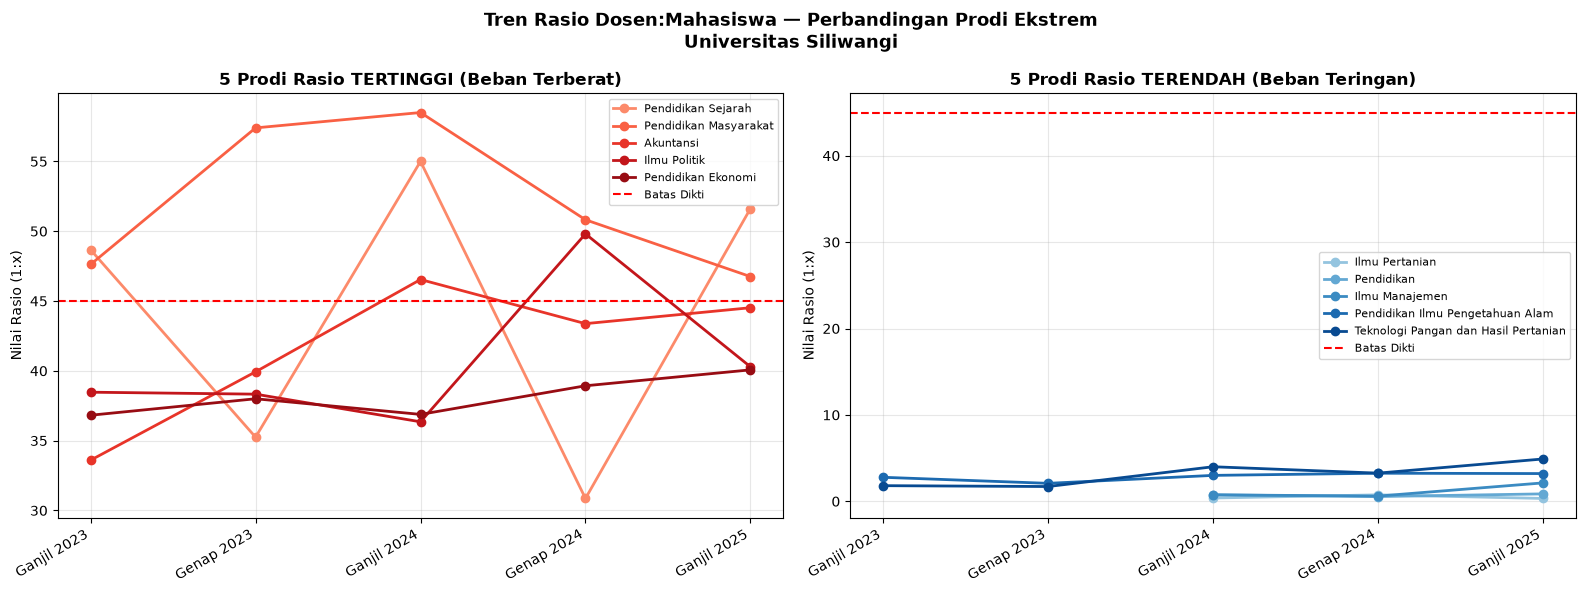

✅ Grafik disimpan ke Google Drive: d:/Code/Tugas Akhir/Outputs/Visualizations\line_tren_top5_bot5.png


In [6]:
# Line chart tren 5 prodi rasio tertinggi vs 5 terendah (periode terbaru)
top5  = df_latest.nlargest(5, 'nilai_rasio')['nama_program_studi'].tolist()
bot5  = df_latest.nsmallest(5, 'nilai_rasio')['nama_program_studi'].tolist()
sel   = top5 + bot5

df_sel = df[df['nama_program_studi'].isin(sel)].copy()
df_sel = df_sel.groupby(['nama_program_studi','tahun_pelaporan'], observed=True)['nilai_rasio'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, group, title, clist in zip(axes, [top5, bot5],
    ['5 Prodi Rasio TERTINGGI (Beban Terberat)','5 Prodi Rasio TERENDAH (Beban Teringan)'],
    [plt.colormaps["Reds"](np.linspace(0.4,0.9,5)), plt.colormaps["Blues"](np.linspace(0.4,0.9,5))]):
    for i, prodi in enumerate(group):
        sub = df_sel[df_sel['nama_program_studi']==prodi]
        ax.plot(sub['tahun_pelaporan'].astype(str), sub['nilai_rasio'],
                marker='o', label=prodi, color=clist[i], linewidth=2)
    ax.axhline(45, color='red', linestyle='--', linewidth=1.5, label='Batas Dikti')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Nilai Rasio (1:x)')
    ax.set_xticklabels([p for p in PERIOD_ORDER], rotation=30, ha='right')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

plt.suptitle('Tren Rasio Dosen:Mahasiswa — Perbandingan Prodi Ekstrem\nUniversitas Siliwangi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PATH_VIZ, 'line_tren_top5_bot5.png'), bbox_inches='tight', dpi=150)
plt.show()
print('✅ Grafik disimpan ke Google Drive:', os.path.join(PATH_VIZ, 'line_tren_top5_bot5.png'))

---
## 4. Tabel Analisis untuk Pembahasan

In [7]:
# Tabel ranking prodi berdasarkan rasio periode terbaru
latest = PERIOD_ORDER[-1]
ranking = df[df['tahun_pelaporan']==latest].groupby('nama_program_studi', observed=True).agg(
    jenjang=('jenjang','first'),
    akreditasi=('akreditasi_prodi','first'),
    total_dosen=('total_dosen','mean'),
    dosen_penghitung_rasio=('jumlah_dosen_penghitung_rasio','mean'),
    jumlah_mahasiswa=('jumlah_mahasiswa','mean'),
    nilai_rasio=('nilai_rasio','mean')
).reset_index()
ranking['total_dosen'] = ranking['total_dosen'].round(0).astype('Int64')
ranking['dosen_penghitung_rasio'] = ranking['dosen_penghitung_rasio'].round(0).astype('Int64')
ranking['jumlah_mahasiswa'] = ranking['jumlah_mahasiswa'].round(0).astype('Int64')
ranking['nilai_rasio'] = ranking['nilai_rasio'].round(2)
ranking['rasio_fmt'] = ranking['nilai_rasio'].apply(lambda x: f'1:{x:.2f}' if pd.notna(x) else '-')
ranking['status_dikti'] = ranking['nilai_rasio'].apply(
    lambda x: 'MELEBIHI BATAS' if pd.notna(x) and x > 45 else ('Data Tidak Tersedia' if pd.isna(x) else 'Normal')
)
ranking = ranking.sort_values('nilai_rasio', ascending=False).reset_index(drop=True)
ranking.index += 1
ranking.index.name = 'Ranking'

print(f'[TABEL 5] Ranking Prodi berdasarkan Rasio — Periode {latest}:')
print(ranking[['nama_program_studi','jenjang','akreditasi','dosen_penghitung_rasio','jumlah_mahasiswa','rasio_fmt','status_dikti']])
print(f'\nJumlah prodi melebihi batas 1:45  : {(ranking["nilai_rasio"] > 45).sum()} prodi')
print(f'Jumlah prodi data tidak tersedia   : {ranking["nilai_rasio"].isna().sum()} prodi')

[TABEL 5] Ranking Prodi berdasarkan Rasio — Periode Ganjil 2025:
                                 nama_program_studi  jenjang  \
Ranking                                                        
1                                Pendidikan Sejarah       S1   
2                             Pendidikan Masyarakat       S1   
3                                         Akuntansi       S1   
4                                      Ilmu Politik       S1   
5                                Pendidikan Ekonomi       S1   
6                               Ekonomi Pembangunan       S1   
7                                  Ekonomi Syari'ah       S1   
8                              Kesehatan Masyarakat       S1   
9                       Pendidikan Bahasa Indonesia       S1   
10                                      Informatika       S1   
11                                             Gizi       S1   
12                                        Manajemen       S1   
13                        Pendidikan Ba

In [8]:
# Tabel prodi yang melebihi batas DIKTI (> 1:45)
pelanggaran = ranking[ranking['nilai_rasio'] > 45][[
    'nama_program_studi','jenjang','dosen_penghitung_rasio','jumlah_mahasiswa','rasio_fmt'
]].copy()
pelanggaran = pelanggaran.rename(columns={
    'nama_program_studi':'Program Studi','jenjang':'Jenjang',
    'dosen_penghitung_rasio':'Dosen Penghitung Rasio',
    'jumlah_mahasiswa':'Mahasiswa','rasio_fmt':'Rasio'
})
print(f'[TABEL 6] Program Studi Melebihi Batas DIKTI (> 1:45) — Periode {latest}:')
if len(pelanggaran) == 0:
    print('Tidak ada prodi yang melebihi batas 1:45 pada periode ini.')
else:
    print(pelanggaran)
    print(f'Total: {len(pelanggaran)} prodi perlu perhatian.')

[TABEL 6] Program Studi Melebihi Batas DIKTI (> 1:45) — Periode Ganjil 2025:
                 Program Studi Jenjang  Dosen Penghitung Rasio  Mahasiswa  \
Ranking                                                                     
1           Pendidikan Sejarah      S1                      13        671   
2        Pendidikan Masyarakat      S1                      12        561   

           Rasio  
Ranking           
1        1:51.62  
2        1:46.75  
Total: 2 prodi perlu perhatian.


---
## 5. Dashboard Final (Semua Chart dalam 1 Tampilan)

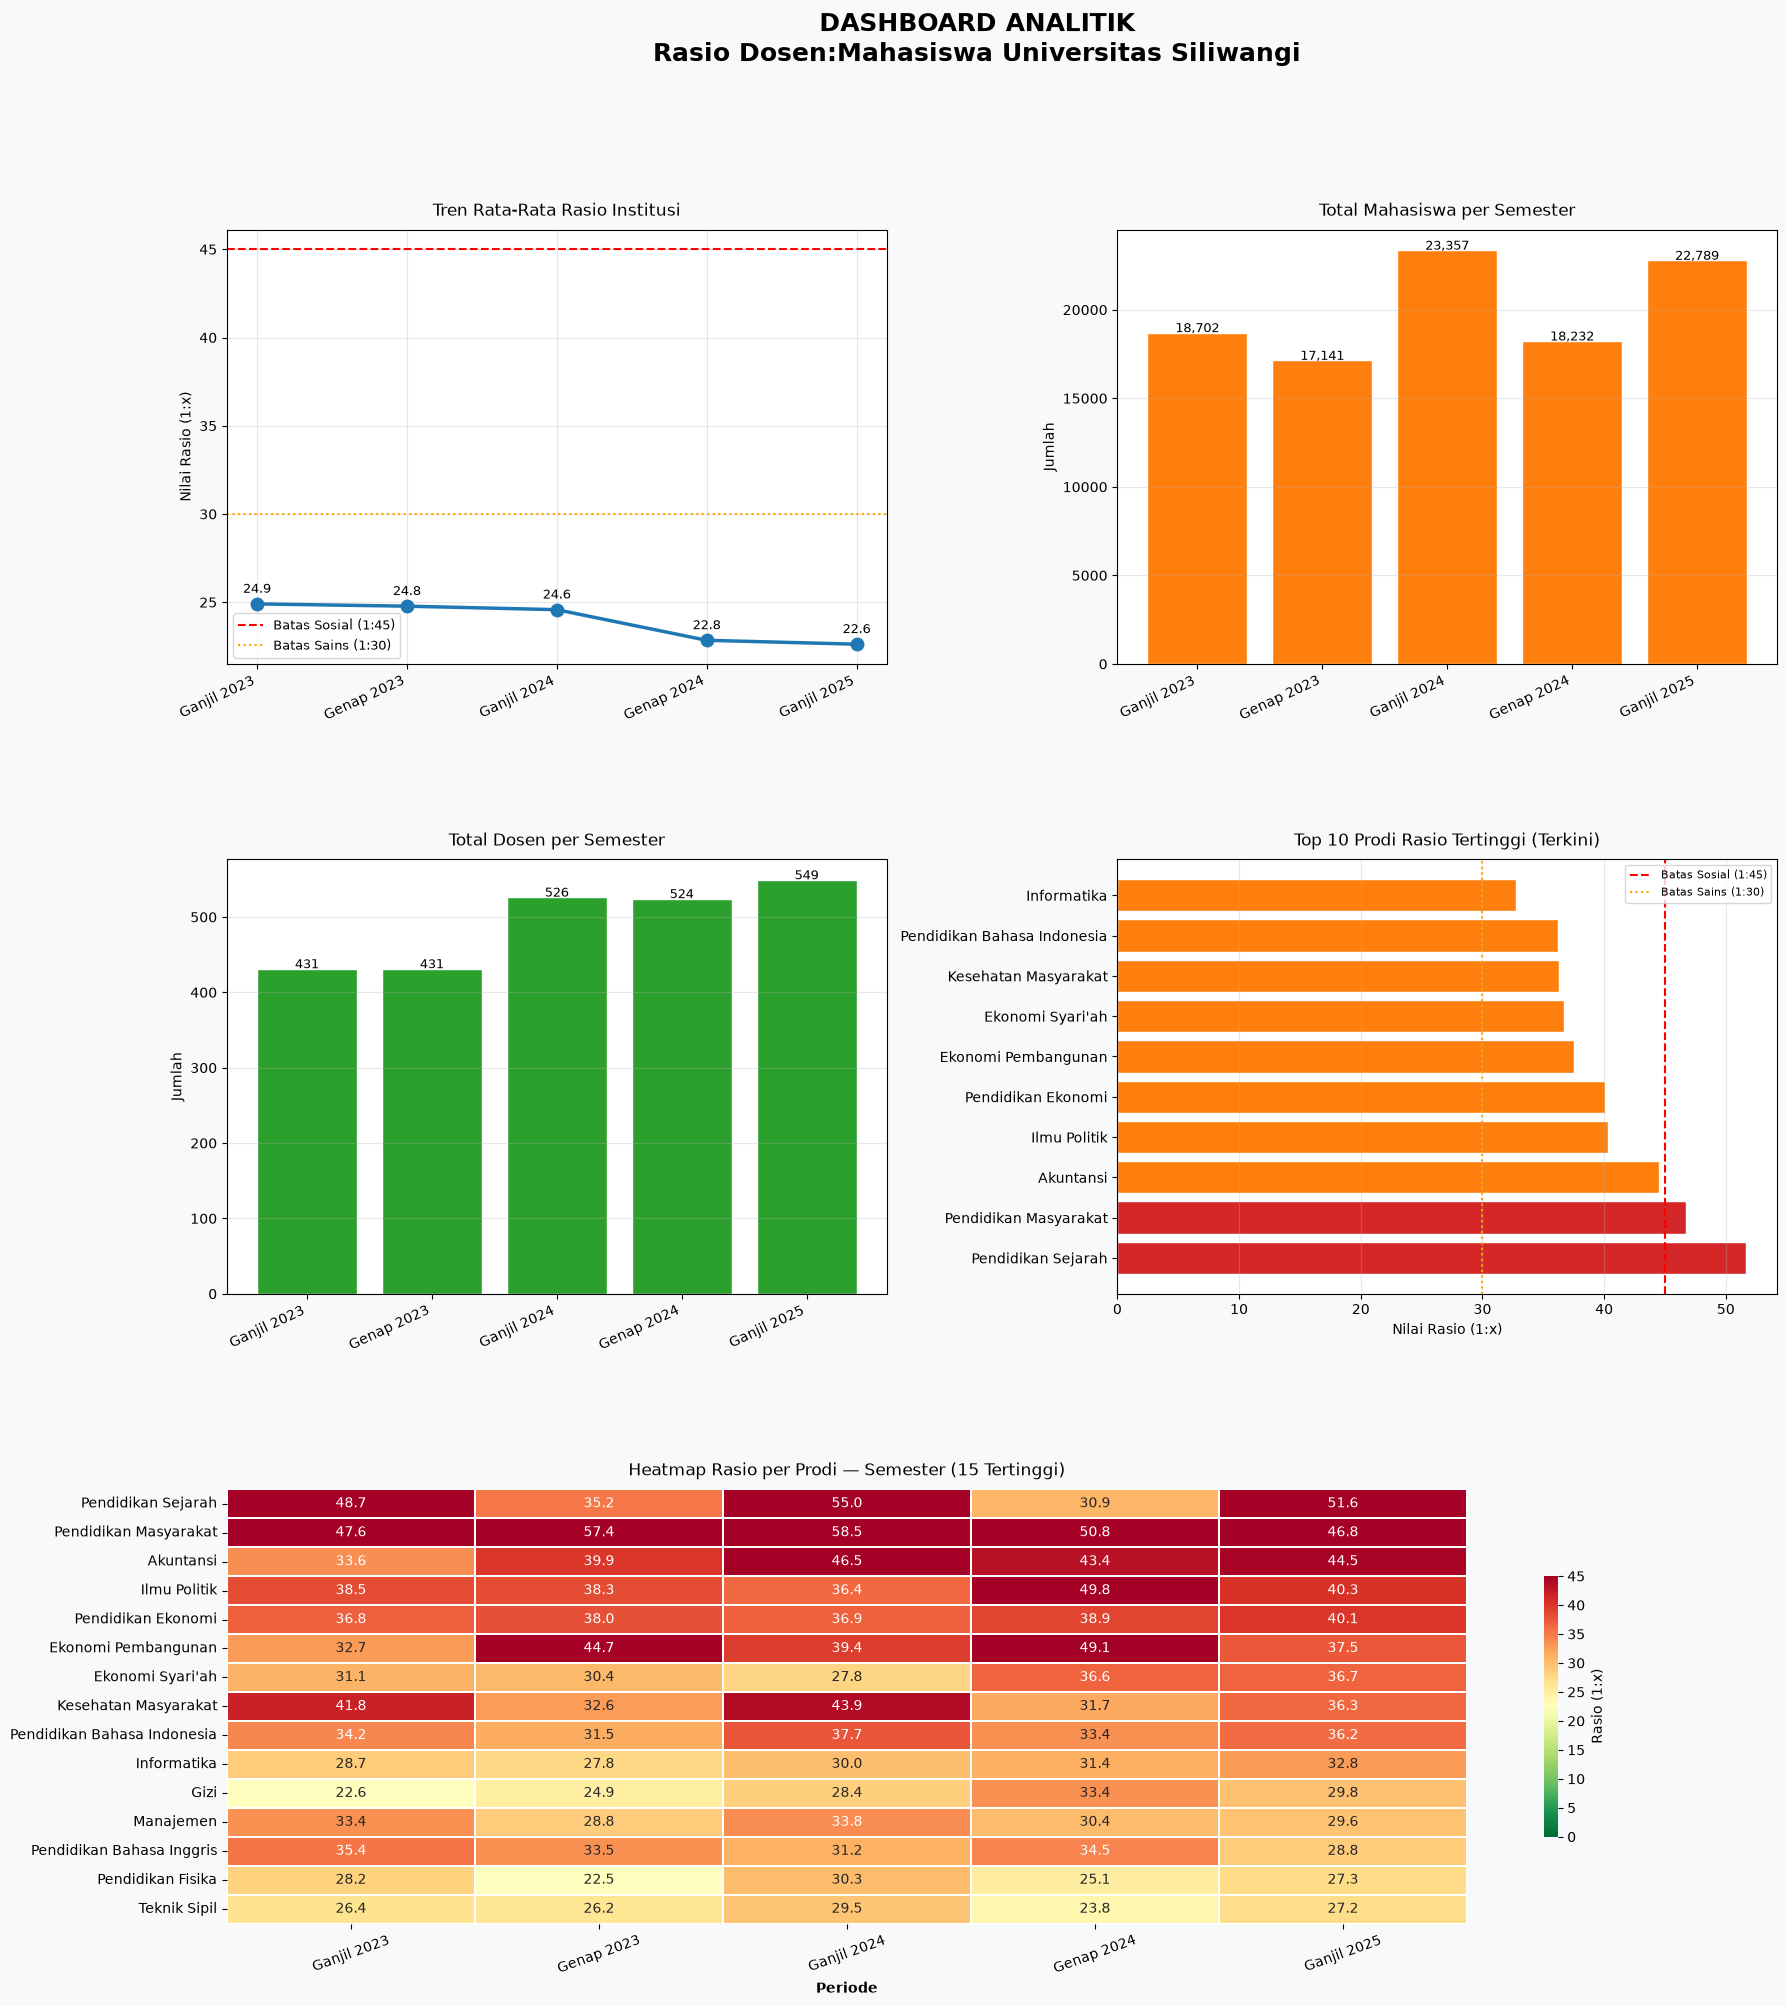

✅ Dashboard tersimpan ke Google Drive: d:/Code/Tugas Akhir/Outputs/Visualizations\dashboard_final.png


In [9]:
fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor('#f8f9fa')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

fig.suptitle('DASHBOARD ANALITIK\nRasio Dosen:Mahasiswa Universitas Siliwangi',
             fontsize=18, fontweight='bold', y=0.98)

# Panel 1: Line tren institusi
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(range(len(inst)), inst['rata_rasio'], marker='o', color='#1f77b4', linewidth=2.5, markersize=9)
ax1.axhline(45, color='red', linestyle='--', linewidth=1.5, label='Batas Sosial (1:45)')
ax1.axhline(30, color='orange', linestyle=':', linewidth=1.5, label='Batas Sains (1:30)')
ax1.set_title('Tren Rata-Rata Rasio Institusi', pad=10)
ax1.set_xticks(range(len(inst))); ax1.set_xticklabels(PERIOD_ORDER, rotation=25, ha='right')
ax1.set_ylabel('Nilai Rasio (1:x)'); ax1.legend(fontsize=9); ax1.grid(alpha=0.3)
for i, v in enumerate(inst['rata_rasio']): ax1.annotate(f'{v:.1f}', (i,v), xytext=(0,8), textcoords='offset points', ha='center', fontsize=9)

# Panel 2: Bar mahasiswa
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(range(len(inst)), inst['total_mahasiswa'], color='#ff7f0e', edgecolor='white')
ax2.set_title('Total Mahasiswa per Semester', pad=10)
ax2.set_xticks(range(len(inst))); ax2.set_xticklabels(PERIOD_ORDER, rotation=25, ha='right')
ax2.set_ylabel('Jumlah'); ax2.grid(alpha=0.3, axis='y')
for i, v in enumerate(inst['total_mahasiswa']): ax2.text(i, v+30, f'{int(v):,}', ha='center', fontsize=9)

# Panel 3: Bar dosen
ax3 = fig.add_subplot(gs[1, 0])
ax3.bar(range(len(inst)), inst['total_dosen'], color='#2ca02c', edgecolor='white')
ax3.set_title('Total Dosen per Semester', pad=10)
ax3.set_xticks(range(len(inst))); ax3.set_xticklabels(PERIOD_ORDER, rotation=25, ha='right')
ax3.set_ylabel('Jumlah'); ax3.grid(alpha=0.3, axis='y')
for i, v in enumerate(inst['total_dosen']): ax3.text(i, v+1, f'{int(v):,}', ha='center', fontsize=9)

# Panel 4: Bar rasio terbaru top 10
ax4 = fig.add_subplot(gs[1, 1])
top10 = df_latest.nlargest(10, 'nilai_rasio')
clrs  = ['#d62728' if v > 45 else '#ff7f0e' if v > 30 else '#1f77b4' for v in top10['nilai_rasio']]
ax4.barh(top10['nama_program_studi'], top10['nilai_rasio'], color=clrs, edgecolor='white')
ax4.axvline(45, color='red', linestyle='--', linewidth=1.5, label='Batas Sosial (1:45)')
ax4.axvline(30, color='orange', linestyle=':', linewidth=1.5, label='Batas Sains (1:30)')
ax4.set_title('Top 10 Prodi Rasio Tertinggi (Terkini)', pad=10)
ax4.set_xlabel('Nilai Rasio (1:x)'); ax4.grid(alpha=0.3, axis='x')
ax4.legend(fontsize=8)

# Panel 5: Heatmap 15 prodi tertinggi
ax5 = fig.add_subplot(gs[2, :])
pivot_dash = pivot.head(15)
sns.heatmap(pivot_dash, annot=True, fmt='.1f', cmap='RdYlGn_r', linewidths=0.3,
            cbar_kws={'label':'Rasio (1:x)', 'shrink':0.6}, ax=ax5, vmin=0, vmax=45)
ax5.set_title('Heatmap Rasio per Prodi — Semester (15 Tertinggi)', pad=10)
ax5.set_xlabel('Periode', fontweight='bold'); ax5.set_ylabel('')
ax5.tick_params(axis='x', rotation=20); ax5.tick_params(axis='y', rotation=0)

plt.savefig(os.path.join(PATH_VIZ, 'dashboard_final.png'), bbox_inches='tight', dpi=150, facecolor=fig.get_facecolor())
plt.show()
print('✅ Dashboard tersimpan ke Google Drive:', os.path.join(PATH_VIZ, 'dashboard_final.png'))
